In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
data=pd.read_csv('test_Y3wMUE5_7gLdaTN.csv')

In [68]:
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


### We load the dataset using pandas. The `head()` function displays the first 5 rows to understand the structure of the data.

In [69]:
data.head()# displays the first five rows in the dataset

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [55]:
data.shape # displays the number of tables and rows 

(367, 12)

In [56]:
data.columns # gives the name of columns present in the dataset 

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

In [57]:
data.dtypes # displays the data types in the dataset

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome      int64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
dtype: object

### 🔍 Observations
- The dataset contains multiple categorical and numerical features.
- Some columns have missing values.

In [58]:
data.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

### 🔍 Insight

- Credit_History has the highest number of missing values.
- Self_Employed and Gender also contain missing values.
- Missing data needs to be handled before modeling.

In [71]:
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].mean())
data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0])

In [72]:
data.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      6
Credit_History        0
Property_Area         0
dtype: int64

### 🧠 Explanation

- The loan amount column is filled using the mean.
- The credit history column is filled using mode.

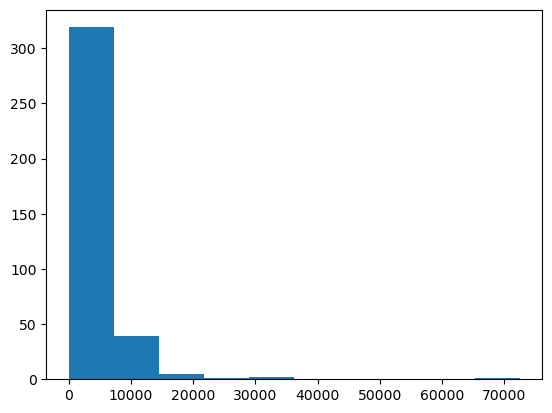

In [73]:
plt.hist(data['ApplicantIncome'])
plt.show()

### 🔍 Insight

The distribution is right-skewed, indicating that most applicants have lower incomes, while a few have very high incomes (outliers).

In [74]:
data['ApplicantIncome'].mean()

np.float64(4805.599455040872)

In [75]:
data['ApplicantIncome'].median()

3786.0

## 1. Skeweness

### 👉 “The distribution of applicant income is positively skewed (right-skewed), indicating that most applicants fall in the lower income range, with a few high-income individuals extending the tail.”

## 2. Outliers 

### 👉 “There are significant outliers in the income distribution, with a few applicants earning extremely high incomes (around 70,000), which may influence statistical measures like the mean.”

## 3. Income Group

### 👉 “The majority of applicants have incomes in the lower range (0–20,000), suggesting that the dataset is dominated by low to middle-income individuals.”

<function matplotlib.pyplot.show(close=None, block=None)>

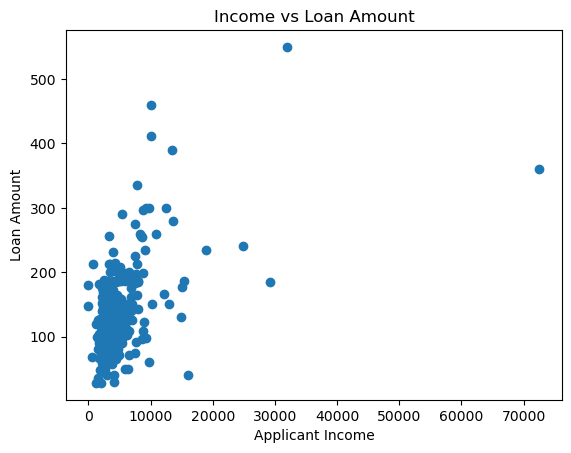

In [62]:
plt.scatter(data['ApplicantIncome'],data['LoanAmount'])
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.title("Income vs Loan Amount")
plt.show 


### 🔍 Insight

“While there is a positive relationship between applicant income and loan amount, the relationship is not strictly proportional. Some applicants with moderate income levels receive higher loan amounts than those with higher income, suggesting that additional factors beyond income influence loan allocation.”

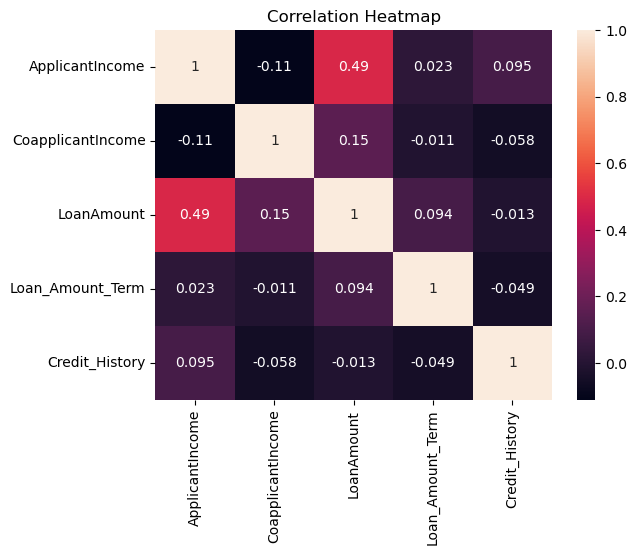

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()


### 🔍 Insights
#### 1, Moderate positive correlation (0.49) between ApplicantIncome and LoanAmount
#### 2, ApplicantIncome has the strongest correlation with LoanAmount.
#### 3, Most relationships are weak; surprisingly, Credit_History shows almost no correlation with LoanAmount.

## KEY FINDINGS  

### .The dataset contains primarily low to middle-income applicants.
### .Applicant income is moderately correlated with loan amount (0.49).
### .Loan amounts are not strictly determined by income, indicating influence from other factors.
### .Coapplicant income has minimal impact on loan amount.
### .Credit history shows very weak correlation with loan amount, which is unexpected.
### .Several features show weak relationships, suggesting complex decision factors.